In [1]:
!pip install yfinance pandas
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
# Define the list of tickers (assets)
tickers = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'INFY.NS']  # Apple, Microsoft, Google, Tesla, Infosys (India)

In [3]:
# Set date range
start_date = '2022-01-01'
end_date = '2023-12-31'

In [4]:
# Download data for all tickers
data = yf.download(tickers, start=start_date, end=end_date)

/tmp/ipykernel_521/2184554015.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  5 of 5 completed


In [5]:
# Show the first 5 rows
data.head()

Price            Close                                                   \
Ticker            AAPL       GOOGL      INFY.NS        MSFT        TSLA   
Date                                                                      
2022-01-03  177.939713  143.717117  1668.151733  322.462433  399.926666   
2022-01-04  175.681366  143.130341  1668.766724  316.933075  383.196655   
2022-01-05  171.008270  136.564041  1620.878174  304.766632  362.706665   
2022-01-06  168.153564  136.536774  1597.285156  302.358429  354.899994   
2022-01-07  168.319778  135.812698  1594.209717  302.512573  342.320007   

Price             High                                                   ...  \
Ticker            AAPL       GOOGL      INFY.NS        MSFT        TSLA  ...   
Date                                                                     ...   
2022-01-03  178.790267  144.569060  1681.859406  325.593136  400.356659  ...   
2022-01-04  178.848915  145.197506  1675.356909  322.895862  402.666656  ...   
2022-01-05  176.140865  143.229440  1672.061950  314.100943  390.113342  ...   
2022-01-06  171.379770  138.710008  1606.247765  307.001509  362.666656  ...   
2022-01-07  170.245725  137.231620  1613.277276  304.882266  360.309998  ...   

Price             Open                                                   \
Ticker            AAPL       GOOGL      INFY.NS        MSFT        TSLA   
Date                                                                      
2022-01-03  173.853197  143.780051  1658.749778  323.040415  382.583344   
2022-01-04  178.545850  144.118073  1668.151575  322.539418  396.516663   
2022-01-05  175.593390  143.150640  1669.513723  313.898631  382.216675   
2022-01-06  168.837907  135.794364  1606.247765  301.655214  359.000000   
2022-01-07  169.023678  136.931274  1595.220126  302.618521  360.123322   

Price            Volume                                                  
Ticker             AAPL       GOOGL    INFY.NS        MSFT         TSLA  
Date                                                                     
2022-01-03  104487900.0  28646000.0  3329616.0  28865100.0  103931400.0  
2022-01-04   99310400.0  28400000.0  3921999.0  32674300.0  100248300.0  
2022-01-05   94537600.0  54618000.0  6995719.0  40054300.0   80119800.0  
2022-01-06   96904000.0  37348000.0  6449205.0  39646100.0   90336600.0  
2022-01-07   86709100.0  29760000.0  4834389.0  32720000.0   84164700.0  

[5 rows x 25 columns]

In [6]:
# Save to CSV
data.to_csv("historical_asset_prices.csv")
print("Saved 'historical_asset_prices.csv'")

Saved 'historical_asset_prices.csv'


**DATA PREPROCESS**

In [7]:
# 2. Convert date column to datetime (if applicable)
if 'Date' in data.columns:
  data['Date'] = pd.to_datetime(data['Date'])
  data = data.sort_values('Date') # Ensure chronological order
  data.set_index('Date', inplace=True)


In [8]:
# 3. Fill or drop missing values
data = data.ffill().bfill()

In [9]:
# 5. Calculate daily returns
daily_returns = data.pct_change().dropna()

In [10]:
# 6. Calculate log returns (useful for some models)
log_returns = np.log(data / data.shift(1)).dropna()

In [11]:
# 7. Summary statistics
print("\nSummary Stats of Daily Returns:")
print(daily_returns.describe())
print("\nLog Returns Sample:")
print(log_returns.head())


Summary Stats of Daily Returns:
Price        Close                                                  \
Ticker        AAPL       GOOGL     INFY.NS        MSFT        TSLA   
count   516.000000  516.000000  516.000000  516.000000  516.000000   
mean      0.000293    0.000162   -0.000185    0.000442   -0.000223   
std       0.018029    0.021629    0.015746    0.019053    0.037312   
min      -0.058679   -0.095094   -0.094227   -0.077156   -0.122422   
25%      -0.009376   -0.012594   -0.008965   -0.010520   -0.020159   
50%       0.000000    0.000000    0.000000    0.000000    0.000164   
75%       0.009611    0.012077    0.009579    0.011640    0.019984   
max       0.088975    0.076557    0.051250    0.082268    0.110002   

Price         High                                                  ...  \
Ticker        AAPL       GOOGL     INFY.NS        MSFT        TSLA  ...   
count   516.000000  516.000000  516.000000  516.000000  516.000000  ...   
mean      0.000263    0.000106   -0.00020

In [12]:
# 8. Save cleaned data if needed
daily_returns.to_csv("cleaned_daily_returns.csv")
log_returns.to_csv("cleaned_log_returns.csv")

**DATA CLEANING**

In [13]:
# 1. Remove duplicate rows
data = data[~data.index.duplicated(keep='first')]

In [14]:
# 2. Fill remaining missing values using forward-fill and back-fill
data = data.fillna(method='ffill').fillna(method='bfill')

/tmp/ipykernel_521/2980099090.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill').fillna(method='bfill')


In [15]:
# 3. Remove outliers using Z-score method (only if needed)
from scipy.stats import zscore
z_scores = np.abs(zscore(data.select_dtypes(include=[np.number])))
data = data[(z_scores < 3).all(axis=1)]

In [16]:
# Cleaned Data Summary
print("Cleaned Dataset Info:")
print(data.info())
print("\nCleaned Dataset Preview:")
print(data.head())

Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 491 entries, 2022-01-03 to 2023-12-29
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, AAPL)      491 non-null    float64
 1   (Close, GOOGL)     491 non-null    float64
 2   (Close, INFY.NS)   491 non-null    float64
 3   (Close, MSFT)      491 non-null    float64
 4   (Close, TSLA)      491 non-null    float64
 5   (High, AAPL)       491 non-null    float64
 6   (High, GOOGL)      491 non-null    float64
 7   (High, INFY.NS)    491 non-null    float64
 8   (High, MSFT)       491 non-null    float64
 9   (High, TSLA)       491 non-null    float64
 10  (Low, AAPL)        491 non-null    float64
 11  (Low, GOOGL)       491 non-null    float64
 12  (Low, INFY.NS)     491 non-null    float64
 13  (Low, MSFT)        491 non-null    float64
 14  (Low, TSLA)        491 non-null    float64
 15  (Open, AAPL)       491 non-null  

In [17]:
# Save cleaned data for further use
data.to_csv("cleaned_asset_prices.csv")


**Markowitz Portfolio Optimization(Efficient Frontier Model)**

In [18]:
import matplotlib.pyplot as plt
from scipy.optimize import minimize
# Step 1: Setup variables
mean_returns = log_returns.mean() * 252 # Annualized return
cov_matrix = log_returns.cov() * 252 # Annualized covariance
num_assets = len(mean_returns)

In [19]:
# Step 2: Portfolio Optimization using Efficient Frontier
def portfolio_performance(weights, mean_returns, cov_matrix):
  returns = np.dot(weights, mean_returns)
  std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
  return returns, std_dev
def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.01):
  p_return, p_std = portfolio_performance(weights, mean_returns, cov_matrix)
  return -(p_return - risk_free_rate) / p_std
def check_sum(weights):
  return np.sum(weights)-1
bounds = tuple((0, 1) for asset in range(num_assets))
initial_weights = num_assets * [1. / num_assets]
constraints = {'type': 'eq', 'fun': check_sum}


In [20]:
# Step 4: Optimize portfolio
optimal = minimize(negative_sharpe_ratio, initial_weights, args=(mean_returns, cov_matrix), method='SLSQP', bounds=bounds, constraints=constraints)

In [21]:
# Step 5: Output
opt_weights = optimal.x
opt_return, opt_risk = portfolio_performance(opt_weights, mean_returns, cov_matrix)
sharpe_ratio = (opt_return - 0.01) / opt_risk
print("Optimal Portfolio Weights:")
for i, asset in enumerate(mean_returns.index):
  print(f"{asset}: {opt_weights[i]:.2%}")
  print(f"\nExpected Return: {opt_return:.2%}")
  print(f"Expected Volatility: {opt_risk:.2%}")
  print(f"Sharpe Ratio: {sharpe_ratio:.2f}")


Optimal Portfolio Weights:
('Close', 'AAPL'): 0.00%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('Close', 'GOOGL'): 0.00%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('Close', 'INFY.NS'): 0.00%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('Close', 'MSFT'): 26.59%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('Close', 'TSLA'): 0.00%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('High', 'AAPL'): 0.00%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('High', 'GOOGL'): 0.00%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('High', 'INFY.NS'): 0.00%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('High', 'MSFT'): 15.88%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('High', 'TSLA'): 0.00%

Expected Return: 6.53%
Expected Volatility: 23.65%
Sharpe Ratio: 0.23
('Low', 

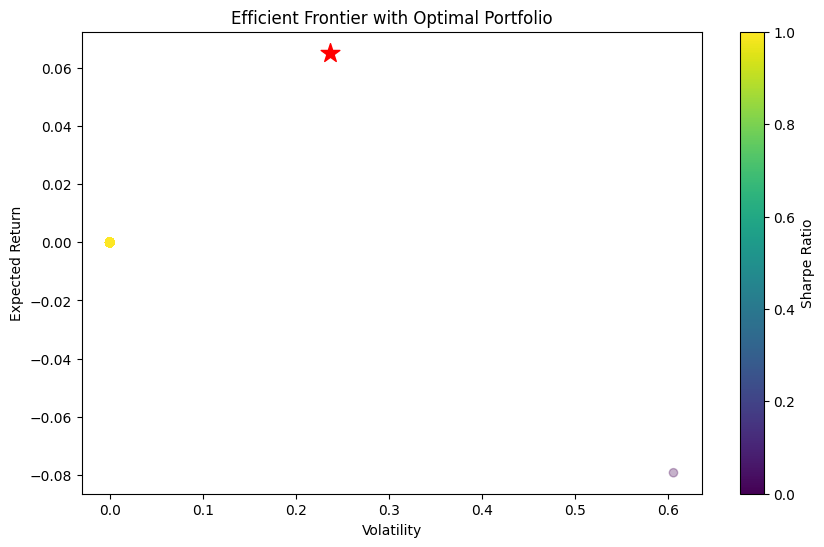

In [22]:
def simulate_random_portfolios(num_portfolios=10000):
  results = np.zeros((3, num_portfolios))
  weight_record = []
  for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weight_record.append(weights)
    portfolio_return, portfolio_std = portfolio_performance(weights, mean_returns, cov_matrix)
    results[0,i] = portfolio_std
    results[1,i] = portfolio_return
    results[2,i] = (portfolio_return - 0.01) / portfolio_std
    return results, weight_record
results, weight_record = simulate_random_portfolios()
plt.figure(figsize=(10, 6))
plt.scatter(results[0,:], results[1,:], c=results[2,:], cmap='viridis', marker='o', alpha=0.3)
plt.scatter(opt_risk, opt_return, color='red', marker='*', s=200)
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.colorbar(label='Sharpe Ratio')
plt.title('Efficient Frontier with Optimal Portfolio')
plt.show()

**CVaR (Conditional Value-at-Risk) Optimization**

In [23]:
from scipy.optimize import minimize
import numpy as np

# Define function to compute portfolio CVaR
def calculate_cvar(weights, returns, alpha=0.05):
    portfolio_returns = returns.dot(weights)
    sorted_returns = np.sort(portfolio_returns)
    index = int(alpha * len(sorted_returns))
    cvar = -np.mean(sorted_returns[:index])  # Negative because loss
    return cvar

# Constraint: weights sum to 1
def constraint(weights):
    return np.sum(weights) - 1

# Bounds: 0 <= weight <= 1
bounds = [(0, 1) for _ in range(len(log_returns.columns))]

# Initial weights (equal)
initial_weights = np.array([1 / len(log_returns.columns)] * len(log_returns.columns))

# Perform the optimization
cvar_result = minimize(
    fun=calculate_cvar,
    x0=initial_weights,
    args=(log_returns, 0.05),
    method='SLSQP',
    bounds=bounds,
    constraints={'type': 'eq', 'fun': constraint}
)

cvar_weights = cvar_result.x
cvar_portfolio = log_returns.dot(cvar_weights)

**Compare This Strategy with Previous Ones**

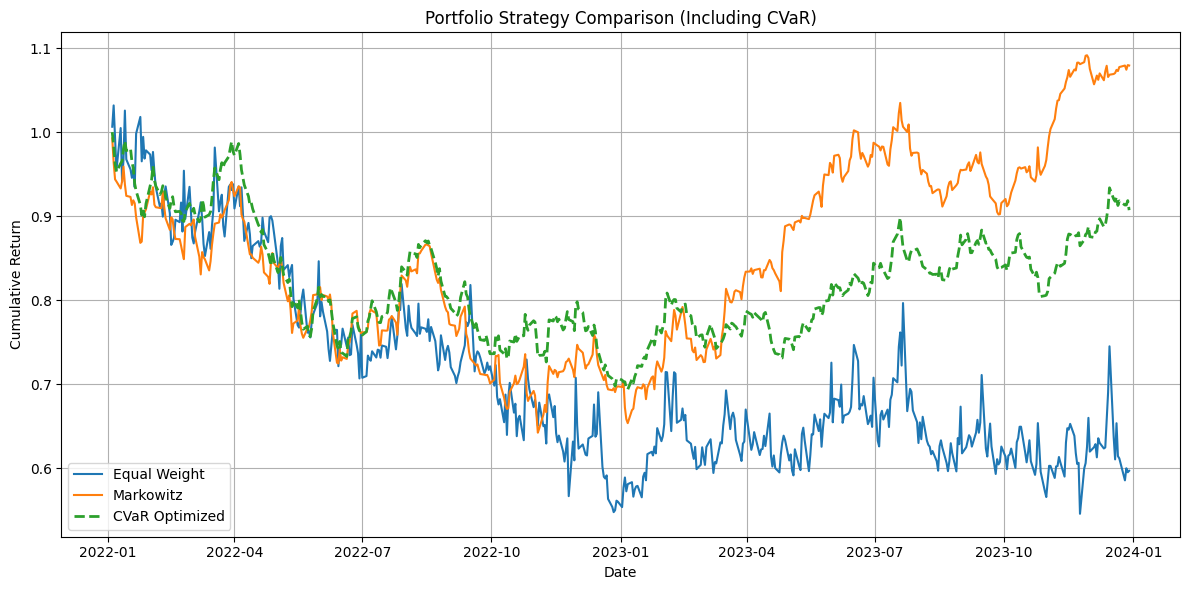

In [24]:
# Cumulative return
cvar_cum = (1 + cvar_portfolio).cumprod()

import matplotlib.pyplot as plt

# Calculate cumulative returns for Equal Weight portfolio
equal_portfolio_returns = log_returns.dot(initial_weights)
equal_cum = (1 + equal_portfolio_returns).cumprod()

# Calculate cumulative returns for Markowitz Optimized portfolio
markowitz_portfolio_returns = log_returns.dot(opt_weights)
markowitz_cum = (1 + markowitz_portfolio_returns).cumprod()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(equal_cum, label="Equal Weight")
plt.plot(markowitz_cum, label="Markowitz")
plt.plot(cvar_cum, label="CVaR Optimized", linestyle="--", linewidth=2.0)
plt.title("Portfolio Strategy Comparison (Including CVaR)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Evaluation Metrices for CVaR Portfolio**

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

total_return = np.exp(cvar_portfolio.sum()) - 1
annualized_return = np.mean(cvar_portfolio) * 252
annualized_volatility = np.std(cvar_portfolio) * np.sqrt(252)
sharpe_ratio = (annualized_return - 0.01) / annualized_volatility
max_drawdown = (cvar_cum / cvar_cum.cummax() - 1).min()

In [26]:
print("📌 CVaR Portfolio Metrics:")
print(f"🔸 Total Return: {total_return:.2%}")
print(f"🔸 Annualized Return: {annualized_return:.2%}")
print(f"🔸 Annualized Volatility: {annualized_volatility:.2%}")
print(f"🔸 Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"🔸 Max Drawdown: {max_drawdown:.2%}")

📌 CVaR Portfolio Metrics:
🔸 Total Return: -5.97%
🔸 Annualized Return: -3.01%
🔸 Annualized Volatility: 18.73%
🔸 Sharpe Ratio: -0.21
🔸 Max Drawdown: -30.65%


**Asset Allocation and Rebalancing**

In [27]:
# Step 1: Initial Portfolio Weights (from Markowitz or User-defined)
initial_weights = np.array([1 / len(data.columns)] * len(data.columns)) # Equal weight for simplicity

In [28]:
# Step 2: Calculate Cumulative Portfolio Value
cumulative_returns = (log_returns + 1).cumprod()
portfolio_value = cumulative_returns.dot(initial_weights)

In [29]:
# Step 3: Calculate current value of each asset in portfolio
final_prices = cumulative_returns.iloc[-1]
portfolio_distribution = initial_weights * final_prices
portfolio_distribution /= portfolio_distribution.sum() # Normalize to sum = 1


In [30]:
# Step 4: Rebalancing Strategy – Equal Weighting
rebalanced_weights = np.array([1 / len(data.columns)] * len(data.columns))

In [31]:
# Step 5: Display before/after weights
asset_names = data.columns
print("🔸 Current Portfolio Allocation:")
for name, w in zip(asset_names, portfolio_distribution):
  print(f"{name}: {w:.2%}")
print("\n🔄 Rebalanced Portfolio Allocation (Equal Weighted):")
for name, w in zip(asset_names, rebalanced_weights):
 print(f"{name}: {w:.2%}")

🔸 Current Portfolio Allocation:
('Close', 'AAPL'): 5.88%
('Close', 'GOOGL'): 5.10%
('Close', 'INFY.NS'): 4.77%
('Close', 'MSFT'): 6.23%
('Close', 'TSLA'): 2.57%
('High', 'AAPL'): 6.03%
('High', 'GOOGL'): 5.24%
('High', 'INFY.NS'): 4.83%
('High', 'MSFT'): 6.35%
('High', 'TSLA'): 2.91%
('Low', 'AAPL'): 6.09%
('Low', 'GOOGL'): 5.23%
('Low', 'INFY.NS'): 4.77%
('Low', 'MSFT'): 6.39%
('Low', 'TSLA'): 2.81%
('Open', 'AAPL'): 6.04%
('Open', 'GOOGL'): 5.14%
('Open', 'INFY.NS'): 4.76%
('Open', 'MSFT'): 6.22%
('Open', 'TSLA'): 2.62%
('Volume', 'AAPL'): 0.00%
('Volume', 'GOOGL'): 0.00%
('Volume', 'INFY.NS'): 0.00%
('Volume', 'MSFT'): 0.00%
('Volume', 'TSLA'): 0.00%

🔄 Rebalanced Portfolio Allocation (Equal Weighted):
('Close', 'AAPL'): 4.00%
('Close', 'GOOGL'): 4.00%
('Close', 'INFY.NS'): 4.00%
('Close', 'MSFT'): 4.00%
('Close', 'TSLA'): 4.00%
('High', 'AAPL'): 4.00%
('High', 'GOOGL'): 4.00%
('High', 'INFY.NS'): 4.00%
('High', 'MSFT'): 4.00%
('High', 'TSLA'): 4.00%
('Low', 'AAPL'): 4.00%
('Low', '

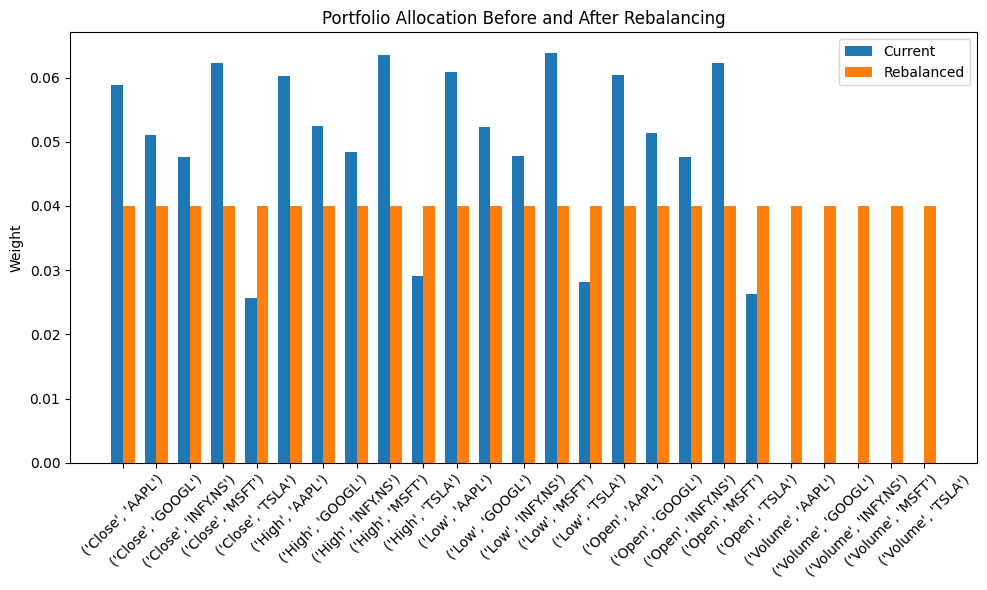

In [32]:
# Step 7: Plot Comparison
x = np.arange(len(asset_names))
width = 0.35
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, portfolio_distribution, width, label='Current')
plt.bar(x + width/2, rebalanced_weights, width, label='Rebalanced')
plt.xticks(x, asset_names, rotation=45)
plt.ylabel('Weight')
plt.title('Portfolio Allocation Before and After Rebalancing')
plt.legend()
plt.tight_layout()
plt.show()

**Predictive Analysis**

In [33]:
#Forecast Asset Price Using Linear Regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import pandas as pd

In [34]:
# Select one asset (you can change this)
asset_name = 'MSFT' # Change this to the desired asset
prices = data[('Close', asset_name)].dropna()
#Step 1: Create lagged features
def create_lagged_features(series, lags=5):
 df = pd.DataFrame()
 for i in range(1, lags + 1):
  df[f'lag_{i}'] = series.shift(i)
  df['target'] = series.values
  df.dropna(inplace=True)
  return df
df = create_lagged_features(prices, lags=5)

In [35]:
# Step 2: Train/Test Split
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:].reset_index(drop=True) # Drop the original index after resetting
X_train = train.drop('target', axis=1)
y_train = train['target']
X_test = test.drop('target', axis=1)
y_test = test['target']


In [36]:
# Step 3: Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
# Step 4: Predict future prices
predictions = model.predict(X_test)
# Evaluate the model
mse = mean_squared_error(y_test, predictions)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 17.24


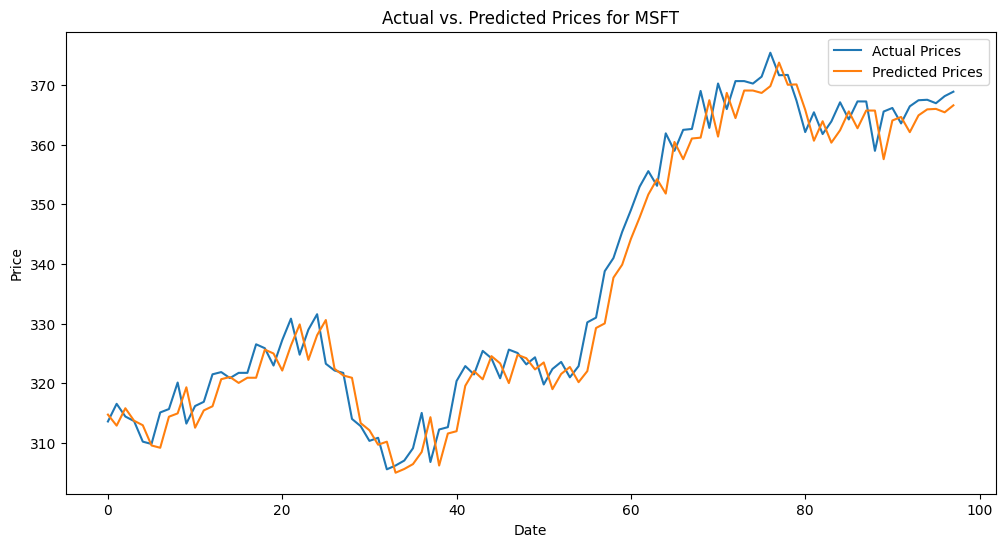

In [37]:
# Visualize the results
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label='Actual Prices')
plt.plot(test.index, predictions, label='Predicted Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'Actual vs. Predicted Prices for {asset_name}')
plt.legend()
plt.show()

**Evaluate Model Accuracy for Forcasting**

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
# Mean Squared Error
mse = mean_squared_error(y_test, predictions)
# Root Mean Squared Error
rmse = np.sqrt(mse)
# Mean Absolute Error
mae = mean_absolute_error(y_test, predictions)
# R-squared (explained variance)
r2 = r2_score(y_test, predictions)
# Print evaluation metrics
print("📊 Model Evaluation Metrics:")
print(f"🔹 MSE (Mean Squared Error) : {mse:.4f}")
print(f"🔸 RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"🟢 MAE (Mean Absolute Error) : {mae:.4f}")
print(f"🟣 R² (R-squared Score) : {r2:.4f}")


📊 Model Evaluation Metrics:
🔹 MSE (Mean Squared Error) : 17.2353
🔸 RMSE (Root Mean Squared Error): 4.1515
🟢 MAE (Mean Absolute Error) : 3.3890
🟣 R² (R-squared Score) : 0.9674


**LSTM-Based Forcasting**

In [39]:
# !pip install tensorflow
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [40]:
# Select one asset (e.g., AAPL or MSFT)
asset_name = 'MSFT'
prices = data[('Close', asset_name)].dropna().values.reshape(-1, 1)

# Normalize prices
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(prices)

In [41]:
# Prepare time series sequences
def create_dataset(series, look_back=60):
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i:i + look_back])
        y.append(series[i + look_back])
    return np.array(X), np.array(y)

look_back = 60  # use past 60 days
X, y = create_dataset(scaled_prices, look_back)

In [42]:
# Train/test split
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# Build LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(look_back, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
# Train
history = model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1, validation_data=(X_test, y_test))

# Predict
predictions = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predicted vs Actual (First 5 rows):")
for p, a in zip(predicted_prices[:5], actual_prices[:5]):
    print(f"Predicted: {p[0]:.2f}, Actual: {a[0]:.2f}")

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 0.0724 - val_loss: 0.0175
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0113 - val_loss: 0.0513
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0077 - val_loss: 0.0044
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0058 - val_loss: 0.0129
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0047 - val_loss: 0.0037
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0042 - val_loss: 0.0049
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0039 - val_loss: 0.0033
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0040 - val_loss: 0.0033
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0036 - val_loss: 0.0032
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0036 - val_loss: 0.0032
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0

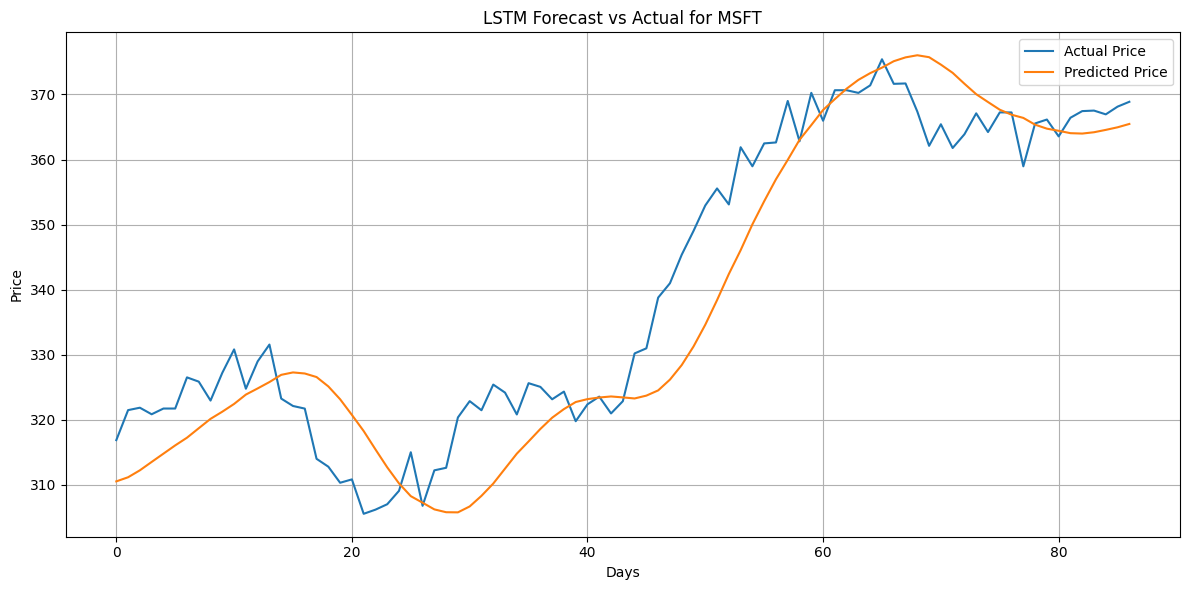

In [44]:
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.title(f'LSTM Forecast vs Actual for {asset_name}')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

**Evaluation of LSTM Model**

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(actual_prices, predicted_prices)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_prices, predicted_prices)
r2 = r2_score(actual_prices, predicted_prices)

print("\n📈 LSTM Model Evaluation:")
print(f"🔹 MSE: {mse:.4f}")
print(f"🔸 RMSE: {rmse:.4f}")
print(f"🟢 MAE: {mae:.4f}")
print(f"🟣 R² Score: {r2:.4f}")


📈 LSTM Model Evaluation:
🔹 MSE: 69.7973
🔸 RMSE: 8.3545
🟢 MAE: 6.7437
🟣 R² Score: 0.8649


In [46]:
# Define a sample portfolio (equal weights for now)
weights = np.array([1 / len(data.columns)] * len(data.columns))
asset_names = data.columns
# Calculate log returns
log_returns = np.log(data / data.shift(1)).dropna()
# Calculate portfolio returns
portfolio_returns = log_returns.dot(weights)
# Performance Metrics
total_return = np.exp(portfolio_returns.sum()) - 1
annualized_return = np.mean(portfolio_returns) * 252
annualized_volatility = np.std(portfolio_returns) * np.sqrt(252)
sharpe_ratio = (annualized_return - 0.01) / annualized_volatility # Assuming 1% risk-free rate

In [47]:
# Asset Allocation
final_prices = data.iloc[-1]
initial_prices = data.iloc[0]
asset_returns = (final_prices / initial_prices - 1).values
allocation_df = pd.DataFrame({ 'Asset': asset_names, 'Weight': weights, 'Asset Return': asset_returns })
# Portfolio Summary
summary = { 'Total Return': total_return, 'Annualized Return': annualized_return, 'Annualized Volatility': annualized_volatility, 'Sharpe Ratio': sharpe_ratio }
# Display summary
print("\n📊 Portfolio Summary:")
for key, value in summary.items():
 print(f"{key}: {value:.2%}")


📊 Portfolio Summary:
Total Return: -11.94%
Annualized Return: -6.54%
Annualized Volatility: 57.55%
Sharpe Ratio: -13.10%


In [48]:
# Display allocation table
print("\n📁 Asset Allocation:")
print(allocation_df)



📁 Asset Allocation:
                Asset  Weight  Asset Return
0       (Close, AAPL)    0.04      0.069885
1      (Close, GOOGL)    0.04     -0.036564
2    (Close, INFY.NS)    0.04     -0.147650
3       (Close, MSFT)    0.04      0.143925
4       (Close, TSLA)    0.04     -0.378686
5        (High, AAPL)    0.04      0.075138
6       (High, GOOGL)    0.04     -0.037648
7     (High, INFY.NS)    0.04     -0.145529
8        (High, MSFT)    0.04      0.136300
9        (High, TSLA)    0.04     -0.362593
10        (Low, AAPL)    0.04      0.091220
11       (Low, GOOGL)    0.04     -0.034325
12     (Low, INFY.NS)    0.04     -0.144430
13        (Low, MSFT)    0.04      0.153260
14        (Low, TSLA)    0.04     -0.346599
15       (Open, AAPL)    0.04      0.102826
16      (Open, GOOGL)    0.04     -0.037399
17    (Open, INFY.NS)    0.04     -0.143847
18       (Open, MSFT)    0.04      0.141757
19       (Open, TSLA)    0.04     -0.333217
20     (Volume, AAPL)    0.04     -0.591607
21    (Volu

In [49]:
# Export to CSV
allocation_df.to_csv("asset_allocation_report.csv", index=False)
pd.DataFrame([summary]).to_csv("portfolio_summary.csv", index=False)

**Market Data Integration**

In [50]:
# Live Market Data Integration (Using yfinance)
import yfinance as yf
import datetime

def live_portfolio_tracking(tickers, weights):
    end_date = datetime.datetime.today()
    start_date = end_date - datetime.timedelta(days=365)

    df = yf.download(tickers, start=start_date, end=end_date)['Close']
    df = df.ffill().bfill()

    log_ret = np.log(df / df.shift(1)).dropna()
    portfolio_returns = log_ret.dot(weights)
    cum_returns = (1 + portfolio_returns).cumprod()

    return cum_returns

/tmp/ipykernel_521/1074721963.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start_date, end=end_date)['Close']
[*********************100%***********************]  5 of 5 completed
/tmp/ipykernel_521/1322787200.py:8: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


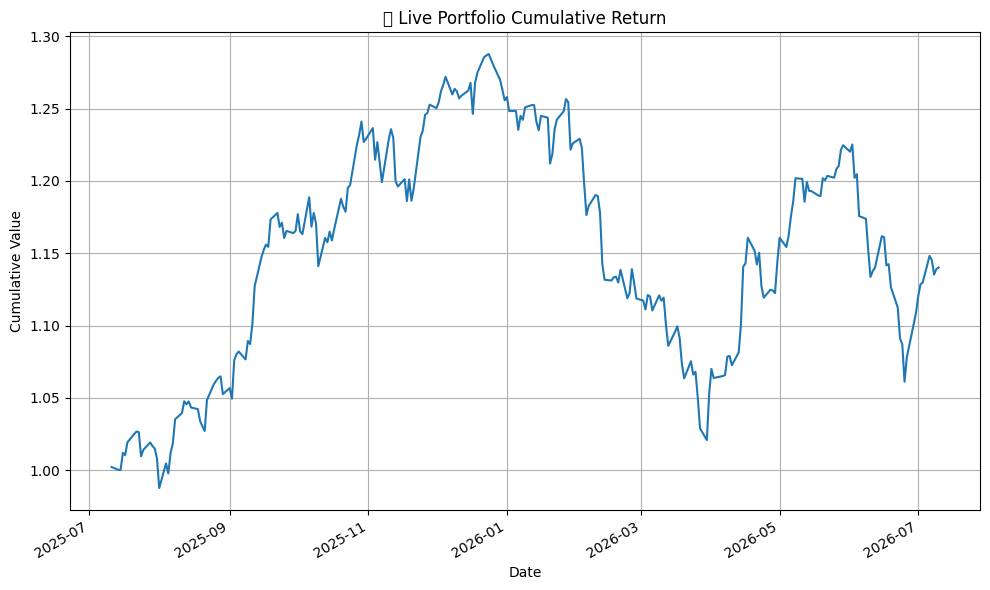

In [51]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'INFY.NS']
weights = [0.2] * 5
live_tracker = live_portfolio_tracking(tickers, weights)

live_tracker.plot(title="📡 Live Portfolio Cumulative Return", figsize=(10,6))
plt.ylabel("Cumulative Value")
plt.grid(True)
plt.tight_layout()
plt.show()

**Incestment Strategy Simulation**

In [52]:
from scipy.optimize import minimize

# Strategy 1: Equal Weight Portfolio
# Ensure weights are created based on the number of columns in log_returns
equal_weights = np.array([1 / len(log_returns.columns)] * len(log_returns.columns))
equal_portfolio = log_returns.dot(equal_weights)

# Strategy 2: Markowitz Optimal Portfolio
def sharpe_ratio(weights, mean_returns, cov_matrix, rf=0.01):
    p_return = np.dot(weights, mean_returns)
    p_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return -(p_return - rf) / p_std

def constraint(weights):
    return np.sum(weights) - 1

# Recalculate mean_returns and cov_matrix based on log_returns
mean_returns = log_returns.mean() * 252
cov_matrix = log_returns.cov() * 252
num_assets = len(log_returns.columns) # Use the number of columns in log_returns

result = minimize(
    sharpe_ratio,
    x0=np.array([1 / num_assets] * num_assets), # Initialize with weights based on num_assets
    args=(mean_returns, cov_matrix),
    method='SLSQP',
    bounds=[(0,1)]*num_assets,
    constraints={'type':'eq', 'fun': constraint}
)

opt_weights = result.x
markowitz_portfolio = log_returns.dot(opt_weights)

In [53]:
# Strategy 3: Top-3 Momentum (update monthly)
def top_n_momentum_strategy(returns, n=3, rebalance_days=21):
    portfolio_returns = []
    index_dates = []
    for i in range(0, len(returns), rebalance_days):
        if i + rebalance_days > len(returns):
            break
        period = returns.iloc[i:i+rebalance_days]
        past_30_return = returns.iloc[i-30:i].mean() if i >= 30 else returns.iloc[:i].mean()
        top_assets = past_30_return.sort_values(ascending=False).head(n).index
        weights = np.array([1/n if col in returns.columns and col in top_assets else 0 for col in returns.columns])
        period_returns = period.dot(weights)
        portfolio_returns.extend(period_returns.tolist())
        index_dates.extend(period.index.tolist())
    return pd.Series(portfolio_returns, index=pd.to_datetime(index_dates))

momentum_portfolio = top_n_momentum_strategy(log_returns)

# Cumulative Returns
equal_cum = (1 + equal_portfolio).cumprod()
markowitz_cum = (1 + markowitz_portfolio).cumprod()
momentum_cum = (1 + momentum_portfolio).cumprod()

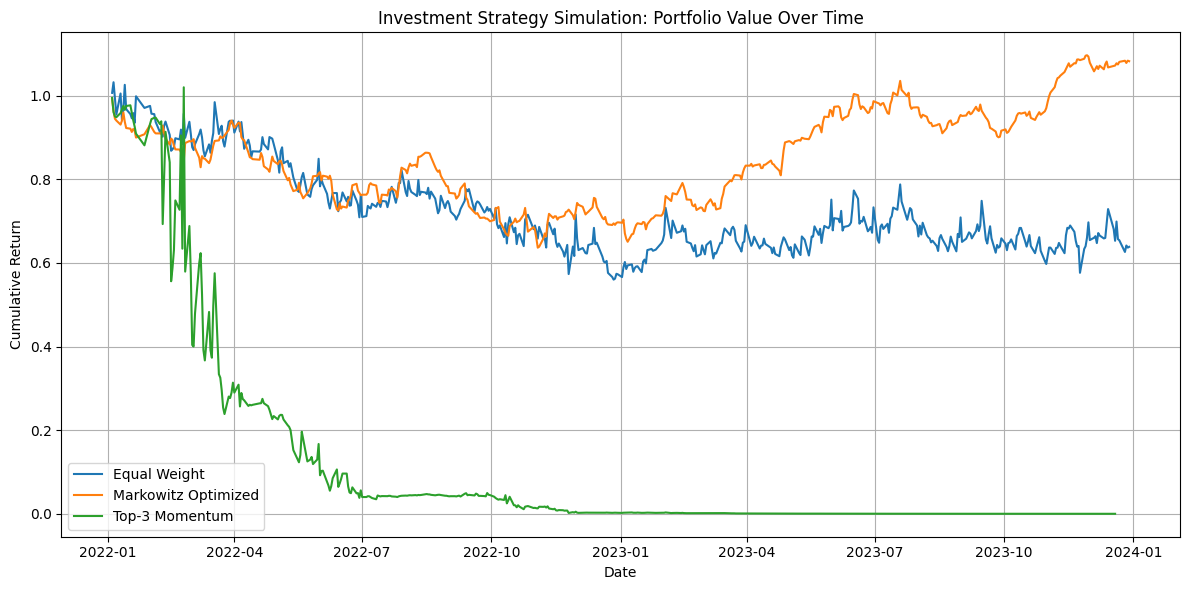

In [54]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(equal_cum.index, equal_cum.values, label='Equal Weight') # Plot values explicitly
plt.plot(markowitz_cum.index, markowitz_cum.values, label='Markowitz Optimized') # Plot values explicitly
plt.plot(momentum_cum.index, momentum_cum.values, label='Top-3 Momentum') # Plot values explicitly
plt.title("Investment Strategy Simulation: Portfolio Value Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Testing & Validation**


🔍 Correlation Between Strategies:
              Equal  Markowitz  Momentum
Equal      1.000000   0.199513  0.686930
Markowitz  0.199513   1.000000 -0.016172
Momentum   0.686930  -0.016172  1.000000


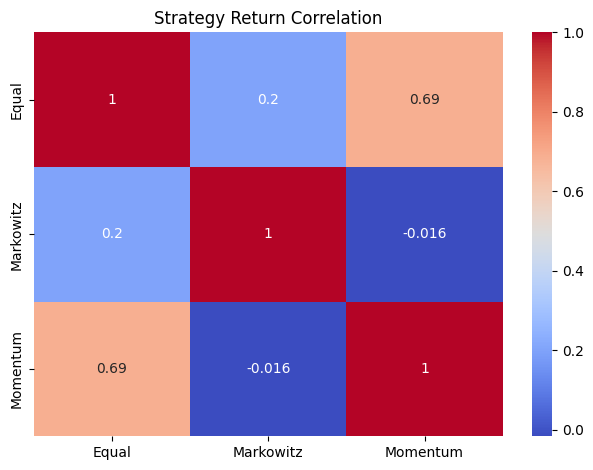

/tmp/ipykernel_521/572347078.py:20: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


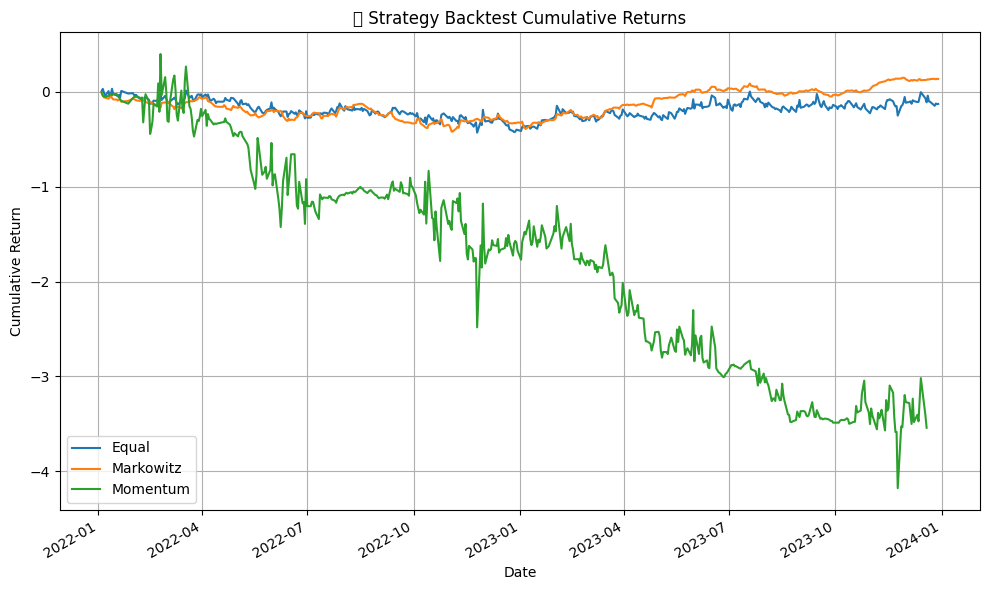

In [55]:
def validate_strategies(returns_dict):
    import seaborn as sns
    import matplotlib.pyplot as plt

    df = pd.DataFrame(returns_dict)
    correlation = df.corr()

    print("\n🔍 Correlation Between Strategies:")
    print(correlation)

    sns.heatmap(correlation, annot=True, cmap="coolwarm")
    plt.title("Strategy Return Correlation")
    plt.tight_layout()
    plt.show()

    df.cumsum().plot(title="📊 Strategy Backtest Cumulative Returns", figsize=(10,6))
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

validate_strategies({
    "Equal": equal_portfolio,
    "Markowitz": markowitz_portfolio,
    "Momentum": momentum_portfolio
})

In [56]:
!pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 104.6 MB/s eta 0:00:00


In [57]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_asset_prices.csv to cleaned_asset_prices (1).csv


In [58]:
df = pd.read_csv(next(iter(uploaded)))
print("File Uploaded Successfully")

File Uploaded Successfully


In [87]:
#app.py
dashboard = """
import streamlit as st
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from datetime import datetime, timedelta

st.set_page_config(layout="wide")

st.title(" 📈Investment Portfolio Optimization Dashboard")
#Upload csv or Download from yfinance
upload = st.file_uploader("upload your historical price csv(optional):",type="csv")
tickers = st.text_input("Enter Ticker Symbols (comma separated)", "AAPL, MSFT, GOOGL, TSLA, INFY.NS").split(",")

start_date = st.date_input("Start Date", datetime(2022, 1, 1))
end_date = st.date_input("End Date", datetime(2023, 12, 31))

if upload:
  data = pd.read_csv(upload, header=[0, 1], index_col=0, parse_dates=True)
  st.success(" ✔ Data uploaded successfully")

else:

  st.info(" 📥 Downloading data from yfinance...")
  data = yf.download(tickers, start = start_date, end = end_date)
  data.to_csv("historical_asset_prices.csv")

#Display Raw Data
st.subheader("📄Raw Data Preview")
st.dataframe(data.head())

# --Clean and Preprocess data
data = data.ffill().bfill()
log_returns = np.log(data['Close'] / data['Close'].shift(1)).dropna()

#Daily Return Summary
st.subheader(" 📊 Daily Log Return Statistics")
st.dataframe(log_returns.describe())

# Portfolio Optimization (Markowitz)
st.subheader(" 📈 Markowitz Portfolio Optimization")

mean_returns = log_returns.mean()* 252
cov_matrix = log_returns.cov() * 252
num_assets = len(mean_returns)

def portfolio_performance(weights):
  ret = np.dot (weights, mean_returns)
  vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
  return ret, vol

def negative_sharpe(weights, risk_free_rate=0.01):
  r, v = portfolio_performance(weights)
  return -(r-risk_free_rate) /v

bounds=tuple((0, 1) for _ in range(num_assets))
init_weights = [1. / num_assets]*num_assets
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
opt = minimize(negative_sharpe, init_weights, bounds=bounds, constraints=constraints)
opt_weights = opt.x
opt_return, opt_vol = portfolio_performance(opt_weights)
sharpe_ratio = (opt_return - 0.01)/opt_vol

st. subheader("🎯Optimal Portfolio weights (Markowitz)")
for asset, weight in zip(mean_returns.index, opt_weights):
  st.write(f"**{asset}**: {weight:.2%}")
st.markdown("---")
st.metric(label=" 📈 Expected Return", value=f"{opt_return:.2%}")
st.metric(label=" 📉 Expected volatility", value=f"{opt_vol:.2%}")
st.metric(label=" ⭐Sharpe Ratio", value=f"{sharpe_ratio:.2f}")

# Plot Efficient Frontier
def simulate_portfolios(n=10000):
  results = np.zeros((3, n))
  weight_record=[]
  for i in range(n):
    w = np.random.random(num_assets)
    w /= np.sum(w)
    weight_record.append(w)
    ret, vol = portfolio_performance(w)
    results[0, i]= vol
    results[1, i] =ret
    results[2, i] =(ret - 0.01) / vol
  return results, weight_record

results, _ = simulate_portfolios()

fig1, ax1 = plt.subplots()
ax1.scatter(results[0], results[1], c=results[2], cmap ='viridis', alpha=0.3)
ax1.scatter(opt_vol, opt_return, color ='red', marker='*', s=200)
ax1.set_title('Efficient Frontier')
ax1.set_xlabel('Volatility')
ax1.set_ylabel('Expected Return')
st.pyplot(fig1)

st.set_page_config(page_title="Asset Price Forecasting (Linear Regression)", layout="centered")
st.title(" 📈 Linear Regression: Asset Price Forecasting Dashboard")

#Show sample data
st.subheader(" Sample Data")
st.write(data.head())

#Asset selection
close_columns = [col for col in data.columns if col[0] == "Close"]
asset_names = [col[1] for col in close_columns]
asset_name = st.selectbox("Select Asset for Forecasting", asset_names)

#Prepare data
prices = data[('Close', asset_name)].dropna()

def create_lagged_features(series, lags=5):
  df = pd.DataFrame()
  for i in range(1, lags + 1):
    df[f'lag_{i}'] = series.shift(i)
  df['target']= series.values
  df.dropna(inplace=True)
  return df

df = create_lagged_features(prices, lags=5)

#Train/test split
train_size = int(len(df)*0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:].reset_index(drop=True)

x_train = train.drop('target', axis=1)
y_train = train['target']
x_test = test.drop('target', axis=1)
y_test = test['target']

#Train model
model = LinearRegression()
model.fit(x_train, y_train)
predictions = model.predict(x_test)

#MSE
mse = mean_squared_error(y_test,predictions)
st.subheader(f" mean Squared Error: {mse:.2f}")

#Plot Result
st.subheader("📊 Actual vs. Predicted Prices")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(test.index, y_test, label='Actual Prices')
ax.plot(test.index, predictions, label='Predicted Prices')
ax.set_xlabel('Time Index')
ax.set_ylabel('price')
ax.set_title(f'Actual vs. Predicted prices for {asset_name}')
ax.legend()
st.pyplot(fig)

#LSTM Forecasting
st.subheader("🤖 LSTM Forecasting")

#Use the corrected prices variable
prices = data[('Close', asset_name.split(' (')[0])].dropna().values.reshape(-1, 1)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)

def create_dataset(series, look_back=60):
  x, y = [],[]
  for i in range(len(series)-look_back):
    x.append(series[i:i + look_back])
    y.append(series[i + look_back])
  return np.array(x), np.array(y)

x, y = create_dataset(scaled)
train_size = int(len(x)*0.8)
x_train, y_train = x[:train_size], y[:train_size]
x_test, y_test = x[train_size:],y[train_size:]

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(60, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss = 'mean_squared_error', optimizer = 'adam')
model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=0)

pred = model.predict(x_test)

predicted = scaler.inverse_transform(pred)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

fig3, ax3 = plt.subplots()
ax3.plot(actual, label = "Actual")
ax3.plot(predicted, label="predicted")
ax3.set_title("LSTM Forecast vs Actual")
ax3.legend()
st.pyplot(fig3)

mse = mean_squared_error(actual, predicted)
st.markdown(f"**LSTM MSE: ** {mse:.2f}")

#Portfolio comparison chart
st.subheader("📊 Strategy Simulation comparison")

equal_weights = np.array([1/num_assets]*num_assets)
equal_portfolio = log_returns.dot(equal_weights)
markowitz_portfolio = log_returns.dot(opt_weights)

def top_n_momentum_strategy(returns, n=3, rebalance_days=21):
  portfolio_returns = []
  index_dates = []
  for i in range(0, len(returns), rebalance_days):
    if i + rebalance_days > len(returns):
      break
    past_return = returns.iloc[max(0,i-30):i].mean()
    top_assets = past_return.sort_values(ascending=False).head(n).index
    weights = [1/n if col in top_assets else 0 for col in returns.columns]
    period_returns = returns.iloc[i:i+rebalance_days].dot(weights)
    portfolio_returns.extend(period_returns)
    index_dates.extend(returns.index[i:i+rebalance_days])
  return pd.Series(portfolio_returns, index=index_dates)

momentum_portfolio = top_n_momentum_strategy(log_returns)

equal_cum = (1 + equal_portfolio).cumprod()
markowitz_cum = (1 + markowitz_portfolio).cumprod()
momentum_cum = (1 + momentum_portfolio).cumprod()

fig4, ax4 = plt.subplots()
ax4.plot(equal_cum, label="Equal Weight")
ax4.plot(markowitz_cum, label="Markowitz Optimized")
ax4.plot(momentum_cum, label="Top-3 Momentum")
ax4.set_title(" 📈 Cumulative  return Comparison")
ax4.legend()
st.pyplot(fig4)

"""
with open("app.py", "w") as f:
  f.write(dashboard)



In [66]:
!pkill streamlit
!Istreamlit run app.py &>/dev/null &

In [89]:
!pip install pyngrok
from pyngrok import ngrok
import time

ngrok.kill()
ngrok.set_auth_token("3GIT7Jjdpp17qppuJadgPZx9hfE_41GtpgiihPk1XuztmBGb9")

#Run Streamlit in background
!streamlit run app.py &>/content/log.txt &

#wait for Streamlit to launch
time.sleep(5)

#Connect to public URL

public_url = ngrok.connect(addr=8501, bind_tls=True)
print(" Streamlit Dashboard URL:", public_url)

 Streamlit Dashboard URL: NgrokTunnel: "https://48b9-34-87-128-41.ngrok-free.app" -> "http://localhost:8501"
